# Smoke Test — Verify Sentinel-2 + DEM + Boreholes Align
Confirms the data pipeline works end-to-end before we build the backend.

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import rasterio
from rasterio.plot import show
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA = Path("../data/raw")
S2 = DATA / "satellite" / "s2_nagpur_smoke_test.tif"
DEM = DATA / "dem" / "dem_nagpur_smoke_test.tif"
HOLES = DATA / "india" / "mn_boreholes_collars.csv"

print(f"S2: {S2.exists()}, DEM: {DEM.exists()}, Holes: {HOLES.exists()}")

Matplotlib is building the font cache; this may take a moment.


S2: True, DEM: True, Holes: True


In [2]:
print("=" * 40, "\nSentinel-2\n", "=" * 40)
with rasterio.open(S2) as src:
    print(f"CRS: {src.crs}, Shape: {src.shape}, Bands: {src.count}")
    print(f"Bounds: {src.bounds}")

print("\n", "=" * 40, "\nDEM\n", "=" * 40)
with rasterio.open(DEM) as src:
    print(f"CRS: {src.crs}, Shape: {src.shape}")
    print(f"Bounds: {src.bounds}")
    print(f"Elevation range: {src.read(1).min():.0f} to {src.read(1).max():.0f} m")

print("\n", "=" * 40, "\nBoreholes\n", "=" * 40)
holes = pd.read_csv(HOLES)
print(f"Rows: {len(holes)}, Columns: {list(holes.columns)[:10]}")
print(holes.head(3))

Sentinel-2
CRS: EPSG:32644, Shape: (4493, 8312), Bands: 6
Bounds: BoundingBox(left=292520.0, bottom=2355400.0, right=458760.0, top=2445260.0)

DEM
CRS: EPSG:4326, Shape: (2880, 5760)
Bounds: BoundingBox(left=79.0, bottom=21.3, right=80.6, top=22.1)


Elevation range: 245 to 861 m

Boreholes
Rows: 46, Columns: ['nuid', 'borehole_no', 'block_name', 'district', 'state', 'lon', 'lat', 'length_m', 'rl_collar_m', 'start_date']
             nuid borehole_no          block_name  district           state  \
0  CRO-23394-2017      GDBH-1  GUDMA-WESTERN-UKWA  BALAGHAT  MADHYA PRADESH   
1  CRO-23394-2017      GDBH-2  GUDMA-WESTERN-UKWA  BALAGHAT  MADHYA PRADESH   
2  CRO-23394-2017      GDBH-3  GUDMA-WESTERN-UKWA  BALAGHAT  MADHYA PRADESH   

         lon        lat  length_m  rl_collar_m  start_date    end_date  \
0  80.445098  21.967274     106.5        597.0  2017-11-05  2017-11-29   
1  80.444227  21.966500     119.4        595.0  2017-11-21  2017-12-22   
2  80.444222  21.968049     167.0        597.0  2017-12-04  2017-12-30   

       type toposheet  
0  Vertical     64C05  
1  Vertical     64C05  
2  Vertical     64C05  


In [3]:
lon_col = "lon" if "lon" in holes.columns else "longitude_dd"
lat_col = "lat" if "lat" in holes.columns else "latitude_dd"
gdf = gpd.GeoDataFrame(
    holes,
    geometry=gpd.points_from_xy(holes[lon_col], holes[lat_col]),
    crs="EPSG:4326",
)
with rasterio.open(S2) as src:
    gdf_s2 = gdf.to_crs(src.crs)
print(f"Boreholes: {len(gdf)}, Bounds (WGS84): {gdf.total_bounds}")

Boreholes: 46, Bounds (WGS84): [79.03527778 21.40861111 80.454752   21.974722  ]


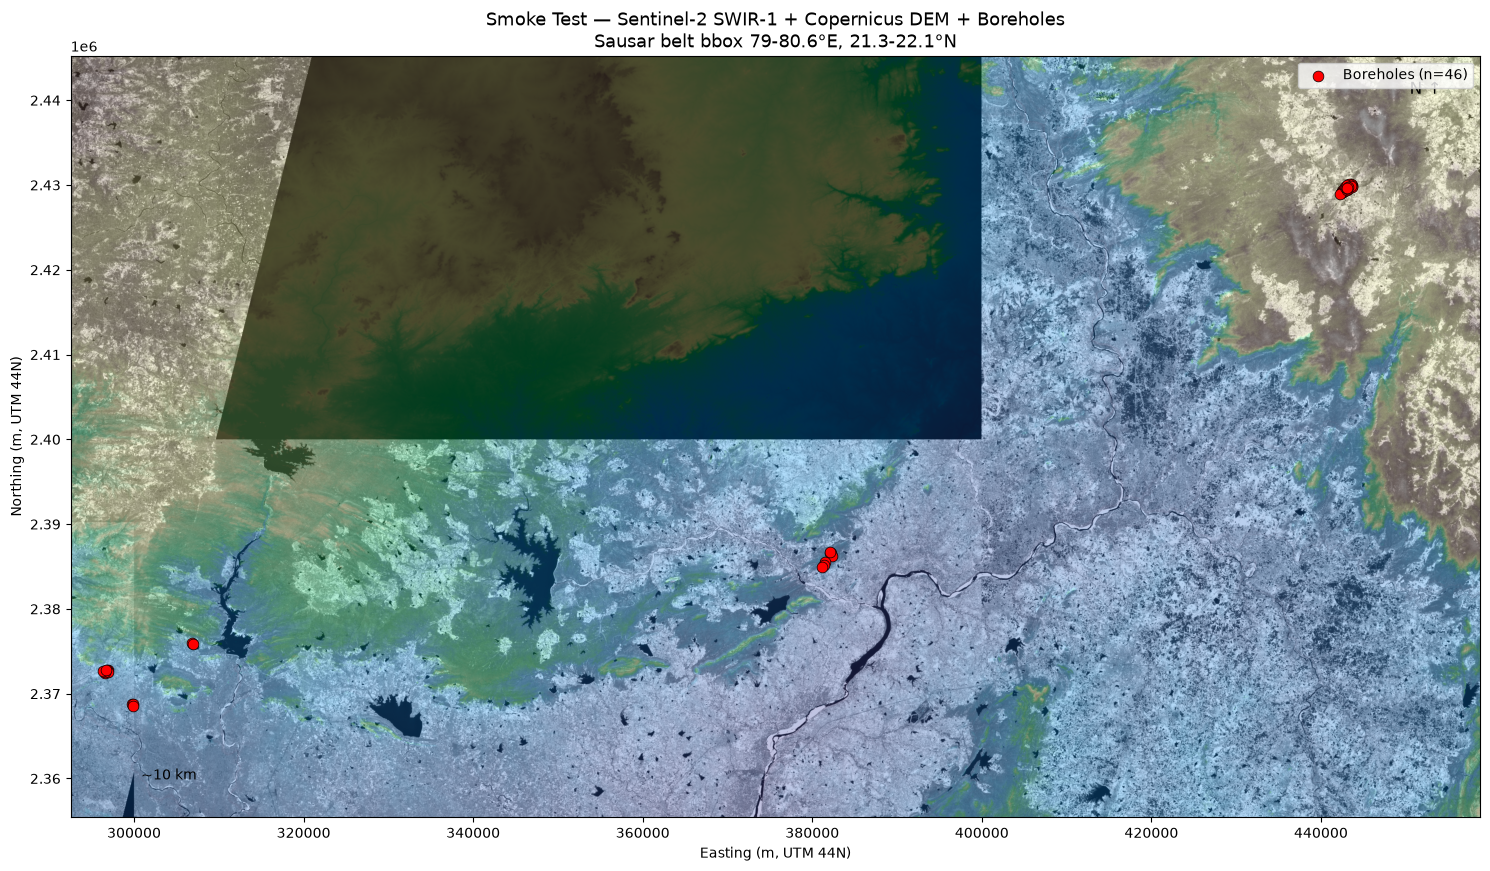

In [4]:
from rasterio.warp import transform_bounds

with rasterio.open(S2) as s2:
    swir1 = s2.read(5)  # B11
    s2_bounds = s2.bounds
    s2_crs = s2.crs
with rasterio.open(DEM) as d:
    dem = d.read(1)
    dem_bounds = d.bounds
    dem_crs = d.crs

# Everything is drawn in the S2 CRS (UTM 44N), so the DEM extent — which is
# stored in EPSG:4326 — has to be projected into metres too.
dem_l, dem_b, dem_r, dem_t = transform_bounds(dem_crs, s2_crs, *dem_bounds)

fig, ax = plt.subplots(figsize=(15, 10))

ax.imshow(
    swir1, cmap="gray",
    extent=[s2_bounds.left, s2_bounds.right, s2_bounds.bottom, s2_bounds.top],
    vmin=np.percentile(swir1, 2), vmax=np.percentile(swir1, 98),
)

dem_show = ax.imshow(
    dem, cmap="terrain", alpha=0.3,
    extent=[dem_l, dem_r, dem_b, dem_t],
)

# gdf_s2 (from the cell above) is in the raster CRS; gdf is in degrees.
ax.scatter(
    gdf_s2.geometry.x, gdf_s2.geometry.y,
    s=60, c="red", edgecolors="black", linewidths=0.5,
    label=f"Boreholes (n={len(gdf_s2)})", zorder=5,
)

ax.set_xlim(s2_bounds.left, s2_bounds.right)
ax.set_ylim(s2_bounds.bottom, s2_bounds.top)
ax.set_title("Smoke Test — Sentinel-2 SWIR-1 + Copernicus DEM + Boreholes\nSausar belt bbox 79-80.6\u00b0E, 21.3-22.1\u00b0N", fontsize=13)
ax.set_xlabel("Easting (m, UTM 44N)"); ax.set_ylabel("Northing (m, UTM 44N)")
ax.legend(loc="upper right")
ax.annotate("N \u2191", xy=(0.95, 0.95), xycoords="axes fraction", fontsize=12)
ax.annotate("~10 km", xy=(0.05, 0.05), xycoords="axes fraction", fontsize=10)
plt.tight_layout()
plt.savefig("smoke_test_map.png", dpi=110, bbox_inches="tight")
plt.show()

In [5]:
from rasterio.warp import transform_bounds

with rasterio.open(S2) as s2:
    s2_b = s2.bounds
    s2_count = s2.count
    s2_crs = s2.crs
with rasterio.open(DEM) as d:
    dem_b = d.bounds
    dem_arr = d.read(1)

checks = {}

# 1. boreholes inside S2 bbox (in S2 CRS)
gdf_check = gdf.to_crs(s2_crs)
minx, miny, maxx, maxy = gdf_check.total_bounds
checks["Boreholes inside S2 bbox"] = (
    minx >= s2_b.left and maxx <= s2_b.right and
    miny >= s2_b.bottom and maxy <= s2_b.top
)

# 2. S2 and DEM overlap (in WGS84)
with rasterio.open(S2) as s2:
    s2_bounds_wgs = transform_bounds(s2.crs, "EPSG:4326", *s2.bounds)
dem_bounds_wgs = dem_b  # already WGS84
overlap_x = min(s2_bounds_wgs[2], dem_bounds_wgs[2]) - max(s2_bounds_wgs[0], dem_bounds_wgs[0])
overlap_y = min(s2_bounds_wgs[3], dem_bounds_wgs[3]) - max(s2_bounds_wgs[1], dem_bounds_wgs[1])
checks["S2 and DEM overlap"] = overlap_x > 0 and overlap_y > 0

# 3. S2 has 6 bands
checks["S2 has 6 bands"] = s2_count == 6

# 4. DEM has valid values
valid_pct = (dem_arr != dem_arr.min()).mean() * 100
checks["DEM valid pixel coverage >90%"] = valid_pct > 90

print("=" * 50)
print("VERIFICATION RESULTS")
print("=" * 50)
for name, passed in checks.items():
    print(f"  {'PASS' if passed else 'FAIL'} \u2014 {name}")

if all(checks.values()):
    print("\n" + "=" * 50)
    print("SMOKE TEST PASSED \u2014 pipeline works end to end")
    print("=" * 50)
else:
    print("\nSMOKE TEST FAILED \u2014 investigate failing checks above")

VERIFICATION RESULTS
  PASS — Boreholes inside S2 bbox
  PASS — S2 and DEM overlap
  PASS — S2 has 6 bands
  PASS — DEM valid pixel coverage >90%

SMOKE TEST PASSED — pipeline works end to end
